In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Création de données  (2 classes)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modèle très complexe (trop de neurones)
overfit_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,)),
    Dense(500, activation='relu'),
    Dense(500, activation='relu'),
    Dense(1, activation='sigmoid')
])

overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = overfit_model.fit(X_train, y_train,
                           epochs=200,
                           validation_data=(X_test, y_test),
                           verbose=1)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.7619 - loss: 0.5317 - val_accuracy: 0.8889 - val_loss: 0.3086
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8619 - loss: 0.3187 - val_accuracy: 0.9000 - val_loss: 0.2294
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8571 - loss: 0.3097 - val_accuracy: 0.8556 - val_loss: 0.2590
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8429 - loss: 0.2908 - val_accuracy: 0.9000 - val_loss: 0.2234
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8429 - loss: 0.2940 - val_accuracy: 0.8778 - val_loss: 0.2454
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8667 - loss: 0.2676 - val_accuracy: 0.8889 - val_loss: 0.2079
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8667 - loss: 0.2463 - val_accuracy: 0.9000 - val_loss: 0.2175
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9000 - loss: 0.2288 - val_accuracy: 0.9000 - val_loss:

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


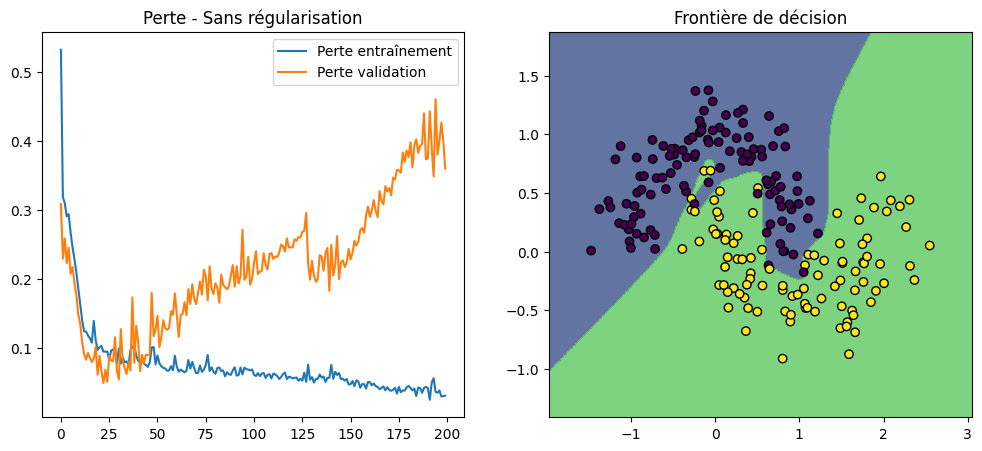

In [19]:
# Courbes d'apprentissage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perte entraînement')
plt.plot(history.history['val_loss'], label='Perte validation')
plt.title('Perte - Sans régularisation')
plt.legend()

# Frontière de décision
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title("Frontière de décision")

plt.subplot(1, 2, 2)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.show()


In [20]:
from tensorflow.keras.regularizers import l2

# Même architecture mais avec régularisation L2
regularized_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])

regularized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

reg_history = regularized_model.fit(X_train, y_train,
                                   epochs=200,
                                   validation_data=(X_test, y_test),
                                   verbose=0)

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


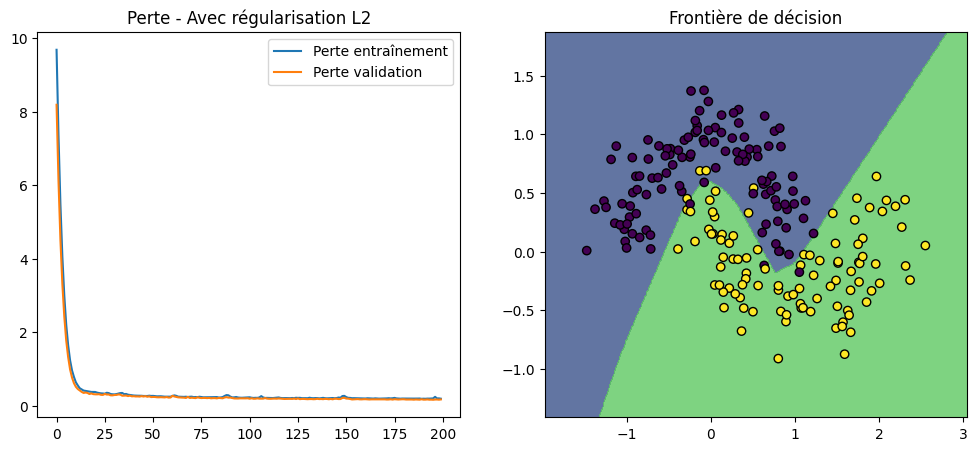

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(reg_history.history['loss'], label='Perte entraînement')
plt.plot(reg_history.history['val_loss'], label='Perte validation')
plt.title('Perte - Avec régularisation L2')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.show()


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step
5172/5172 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step


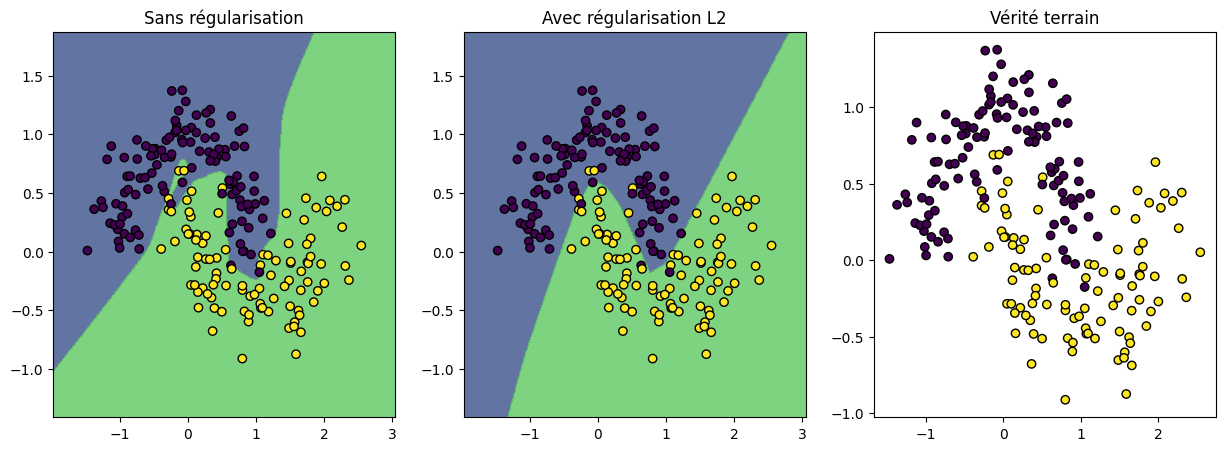

In [22]:
plt.figure(figsize=(15, 5))

# Sans régularisation
plt.subplot(1, 3, 1)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.title("Sans régularisation")

# Avec régularisation
plt.subplot(1, 3, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.title("Avec régularisation L2")

# Vérité terrain
plt.subplot(1, 3, 3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.title("Vérité terrain")
plt.show()

### To DO
Dans le notebook Regularisation.ipynb, tu as déjà implémenté un modèle sur-paramétré (3 couches de 500 neurones) et tu as appliqué une régularisation L2 (kernel_regularizer=l2(0.01)).
Je souhaite que tu complètes ce TP en testant également :

La régularisation L1 (lasso)

La régularisation L1 + L2 (ElasticNet)

### Travail à réaliser
#### 1. Créer deux nouveaux modèles
Copie la structure du modèle regularized_model et remplace la régularisation :

Modèle avec L1 : utilise kernel_regularizer=l1(0.01)

Modèle avec ElasticNet : utilise kernel_regularizer=l1_l2(l1=0.01, l2=0.01)

N'oublie pas d'importer les régulariseurs correspondants :

python
``from tensorflow.keras.regularizers import l1, l1_l2``
#### 2. Entraîner chaque modèle
Entraîne-les sur les mêmes données (X_train, y_train) avec les mêmes paramètres :

epochs = 200

validation_data = (X_test, y_test)

verbose = 0 (pour ne pas polluer la sortie)

Stocke leurs historiques (history_l1, history_elastic).

#### 3. Visualiser les courbes d’apprentissage et les frontières de décision
Pour chaque modèle, produit une figure similaire à celle que tu as déjà utilisée pour L2 :

À gauche : évolution de la loss (train et validation)

À droite : frontière de décision sur les données d’entraînement

#### 4. Comparaison finale
Génère une figure avec 4 sous‑figures (ou deux figures côte à côte) :

Sans régularisation (modèle overfit)

Avec L2

Avec L1

Avec ElasticNet

Ajoute également un titre explicatif sur l’effet observé (par exemple : L1 rend la frontière plus simple, L2 plus lisse, ElasticNet un compromis).

In [17]:

# Étape 1 : Modèle avec régularisation L1 (Lasso)

from tensorflow.keras.regularizers import l1, l1_l2

# Même architecture avec régularisation L1
l1_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l1(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(1, activation='sigmoid')
])

l1_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_l1 = l1_model.fit(X_train, y_train,
                           epochs=200,
                           validation_data=(X_test, y_test),
                           verbose=0)
print(" Modèle L1 entraîné avec succès")

 Modèle L1 entraîné avec succès


In [23]:

# Étape 2 : Modèle avec régularisation ElasticNet (L1 + L2)


# Même architecture avec régularisation ElasticNet
elastic_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(1, activation='sigmoid')
])

elastic_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_elastic = elastic_model.fit(X_train, y_train,
                                    epochs=200,
                                    validation_data=(X_test, y_test),
                                    verbose=0)
print(" Modèle ElasticNet entraîné avec succès")

 Modèle ElasticNet entraîné avec succès


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step


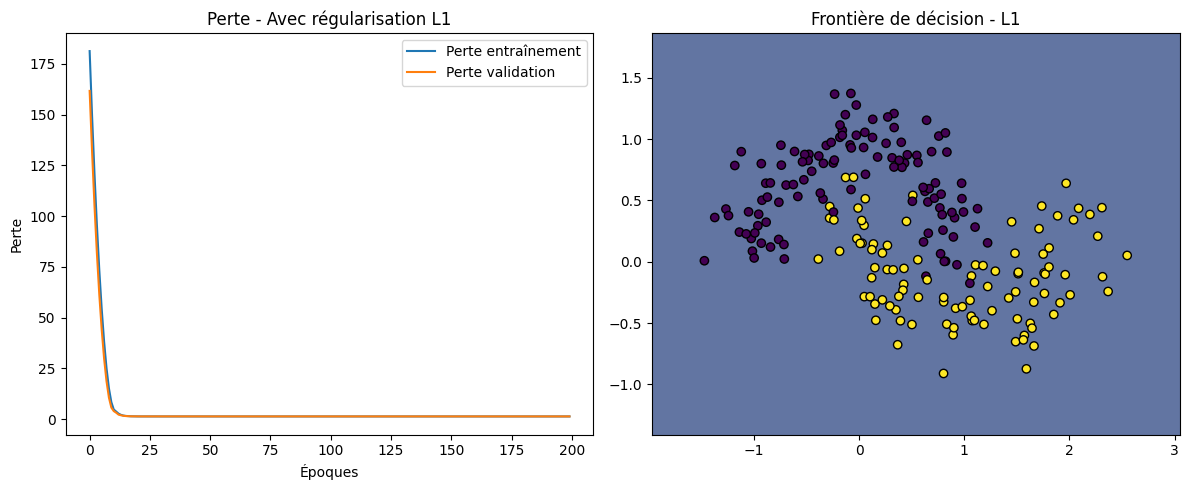

In [24]:

# Étape 3a : Courbes d'apprentissage - Modèle L1


plt.figure(figsize=(12, 5))

# Courbe de perte
plt.subplot(1, 2, 1)
plt.plot(history_l1.history['loss'], label='Perte entraînement')
plt.plot(history_l1.history['val_loss'], label='Perte validation')
plt.title('Perte - Avec régularisation L1')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

# Frontière de décision
plt.subplot(1, 2, 2)
plot_decision_boundary(l1_model, X_train, y_train)
plt.title("Frontière de décision - L1")

plt.tight_layout()
plt.show()

5172/5172 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step


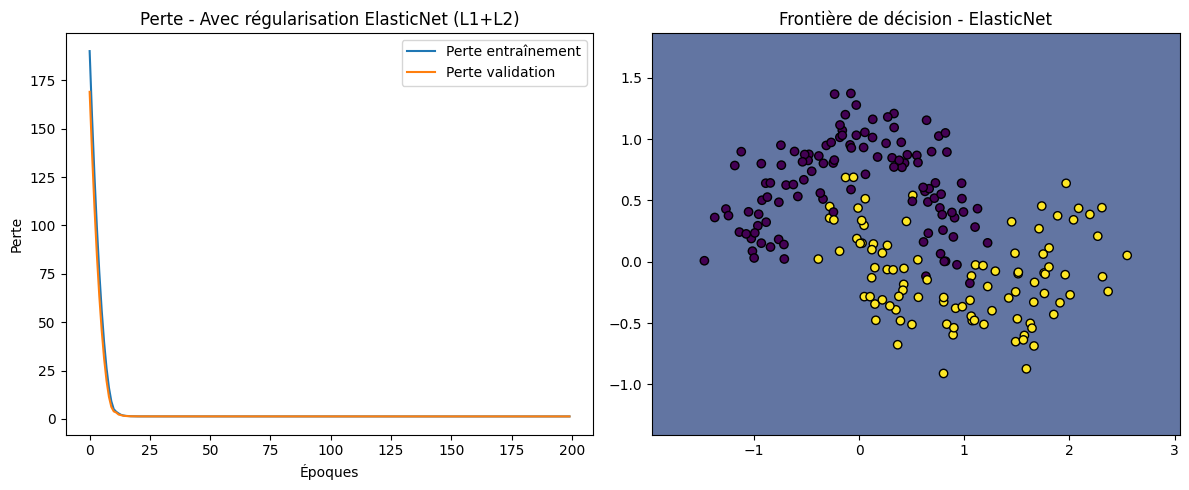

In [25]:

# Étape 3b : Courbes d'apprentissage - Modèle ElasticNet


plt.figure(figsize=(12, 5))

# Courbe de perte
plt.subplot(1, 2, 1)
plt.plot(history_elastic.history['loss'], label='Perte entraînement')
plt.plot(history_elastic.history['val_loss'], label='Perte validation')
plt.title('Perte - Avec régularisation ElasticNet (L1+L2)')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

# Frontière de décision
plt.subplot(1, 2, 2)
plot_decision_boundary(elastic_model, X_train, y_train)
plt.title("Frontière de décision - ElasticNet")

plt.tight_layout()
plt.show()

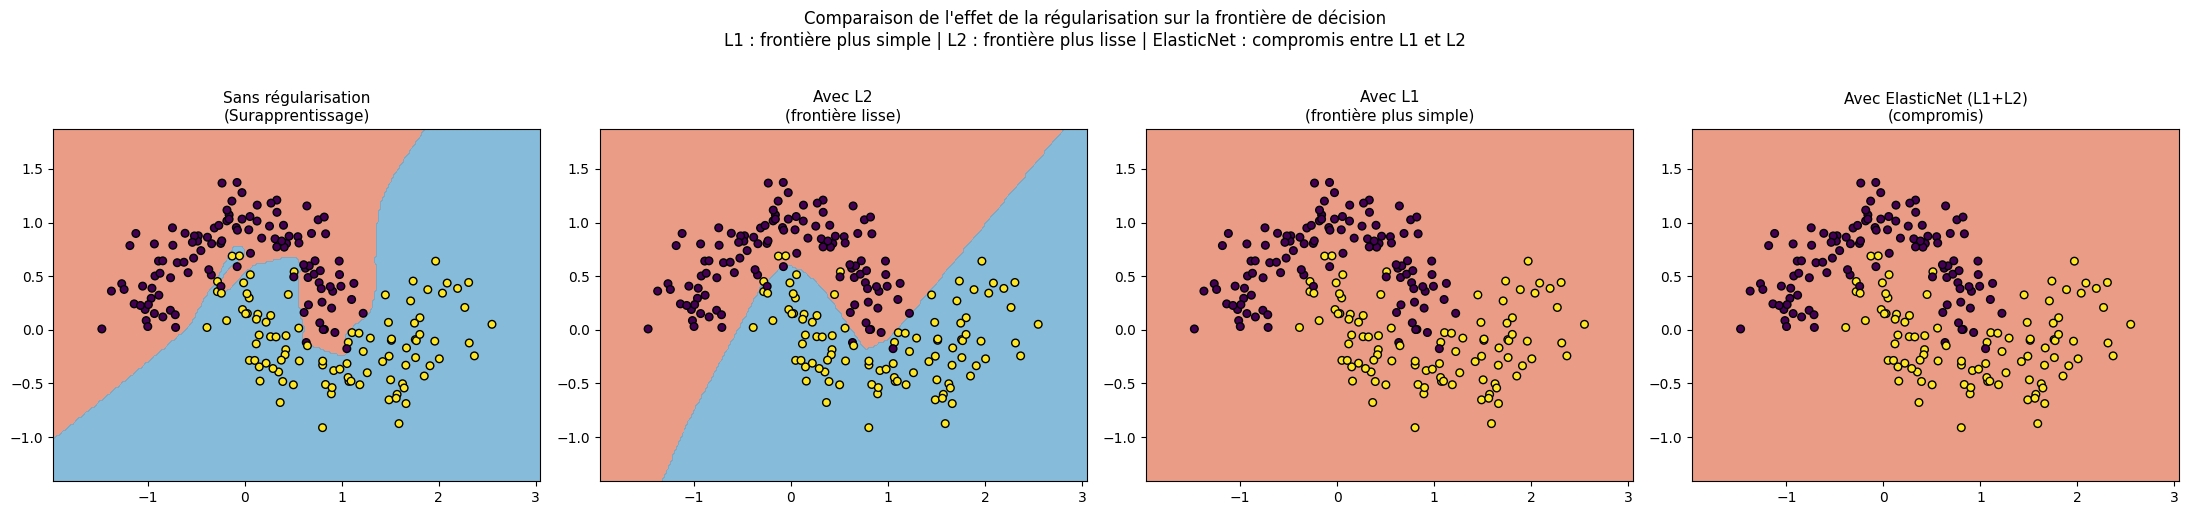

 Figure de comparaison sauvegardée


In [26]:

# Étape 4 : Comparaison finale - 4 modèles


fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    'Comparaison de l\'effet de la régularisation sur la frontière de décision\n'
    'L1 : frontière plus simple | L2 : frontière plus lisse | ElasticNet : compromis entre L1 et L2',
    fontsize=12, y=1.02
)

modeles_info = [
    (overfit_model,     "Sans régularisation\n(Surapprentissage)"),
    (regularized_model, "Avec L2\n(frontière lisse)"),
    (l1_model,          "Avec L1\n(frontière plus simple)"),
    (elastic_model,     "Avec ElasticNet (L1+L2)\n(compromis)"),
]

for ax, (modele, titre) in zip(axes, modeles_info):
    plt.sca(ax)
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = modele.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap='RdBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', s=30)
    ax.set_title(titre, fontsize=11)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('comparaison_regularisation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure de comparaison sauvegardée")

In [27]:

# Étape 5 : Tableau comparatif des précisions finales


modeles_dict = {
    'Sans régularisation': overfit_model,
    'L2 (Ridge)':          regularized_model,
    'L1 (Lasso)':          l1_model,
    'ElasticNet (L1+L2)':  elastic_model,
}

print(f"{'Modèle':<25} {'Préc. entraîn.':>15} {'Préc. test':>12}")
print('-' * 55)
for nom, modele in modeles_dict.items():
    _, prec_train = modele.evaluate(X_train, y_train, verbose=0)
    _, prec_test  = modele.evaluate(X_test,  y_test,  verbose=0)
    print(f"{nom:<25} {prec_train:>15.4f} {prec_test:>12.4f}")

print()
print(" Observations :")
print("  - L1 favorise des poids épars (sparse) → frontière de décision plus simple")
print("  - L2 pénalise les grands poids → frontière de décision plus lisse")
print("  - ElasticNet combine les deux → équilibre entre simplicité et régularité")

Modèle                     Préc. entraîn.   Préc. test
-------------------------------------------------------
Sans régularisation                0.9857       0.9778
L2 (Ridge)                         0.9571       0.9778
L1 (Lasso)                         0.5333       0.4222
ElasticNet (L1+L2)                 0.5333       0.4222

 Observations :
  - L1 favorise des poids épars (sparse) → frontière de décision plus simple
  - L2 pénalise les grands poids → frontière de décision plus lisse
  - ElasticNet combine les deux → équilibre entre simplicité et régularité
